In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/advertising-sales-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.25k/2.25k [00:00<00:00, 3.72MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/advertising-sales-dataset/versions/1


In [2]:
import os
import pandas as pd
csv_file=[f for f in os.listdir(path) if f.endswith('.csv')]
df=pd.read_csv(os.path.join(path,csv_file[0]))
df.head()


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
print(df.duplicated().sum())

0


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


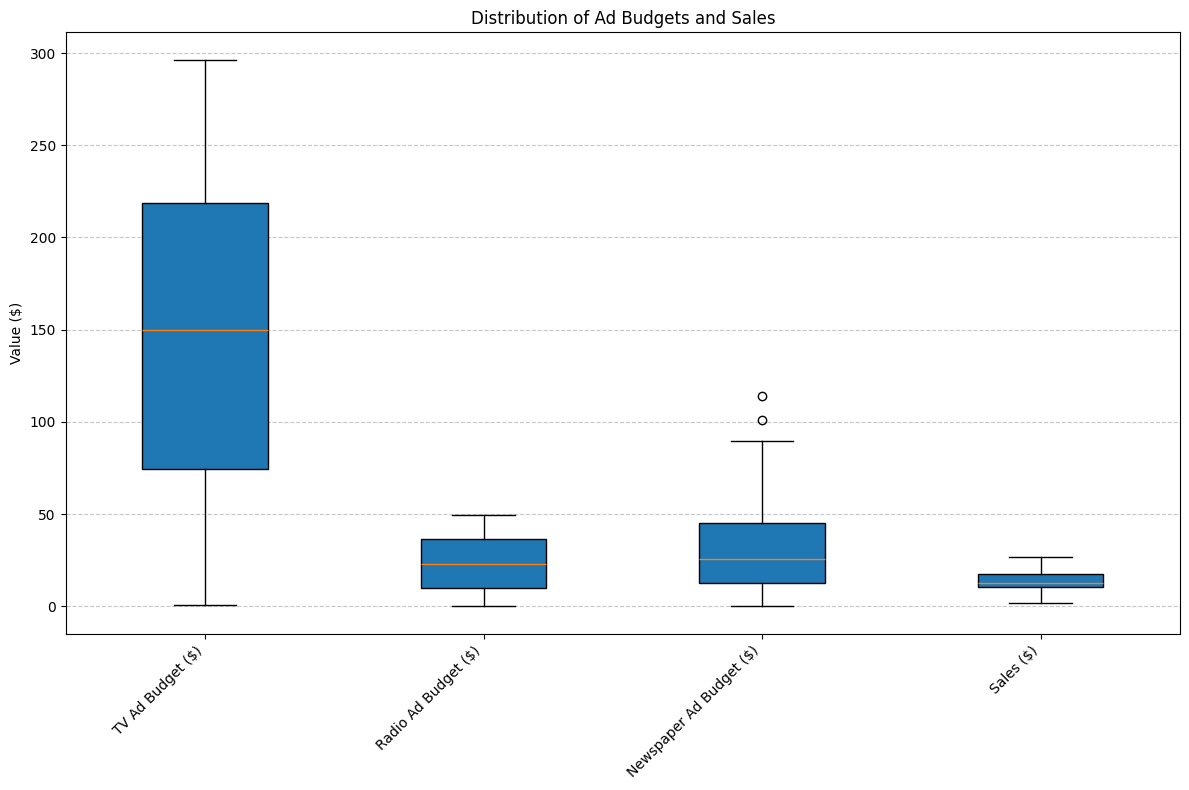

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns # Still useful for aesthetics if you want, but not strictly for the boxplot itself here
import pandas as pd

columns_to_plot = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']


data_to_plot = [df[col] for col in columns_to_plot]

plt.figure(figsize=(12, 8))

plt.boxplot(data_to_plot, patch_artist=True)

plt.xticks(ticks=range(1, len(columns_to_plot) + 1), labels=columns_to_plot, rotation=45, ha='right')

plt.title('Distribution of Ad Budgets and Sales')
plt.ylabel('Value ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

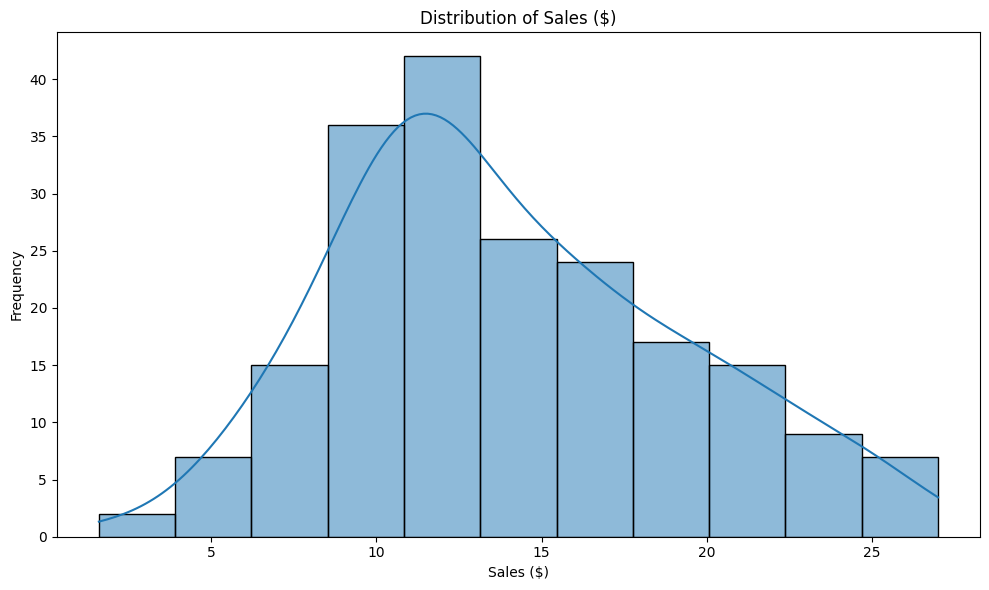

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Sales ($)'], kde=True)
plt.title('Distribution of Sales ($)')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [8]:
df.head(10)

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [9]:
essential_columns=['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']
x=df[essential_columns]
y=df['Sales ($)']
print(f"features: {x.shape}, target: {y.shape}")

features: (200, 3), target: (200,)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

print(f"Training rows {x_train.shape[0]}")
print(f"Testing rows {x_test.shape[0]}")

Training rows 160
Testing rows 40


In [11]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [12]:
print(f"intercept: {model.intercept_:.2f}")
coeff_df=pd.DataFrame(model.coef_,x.columns,columns=['coefficient'])
print(coeff_df.sort_values('coefficient',ascending=False))

intercept: 2.98
                         coefficient
Radio Ad Budget ($)         0.189195
TV Ad Budget ($)            0.044730
Newspaper Ad Budget ($)     0.002761


In [13]:
y_pred=model.predict(x_test)

In [14]:
from sklearn.metrics import mean_absolute_error, r2_score
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(f"r2 score: {r2:.2f}")
print(f"mean absolute error: {mae:.2f}")

r2 score: 0.90
mean absolute error: 1.46


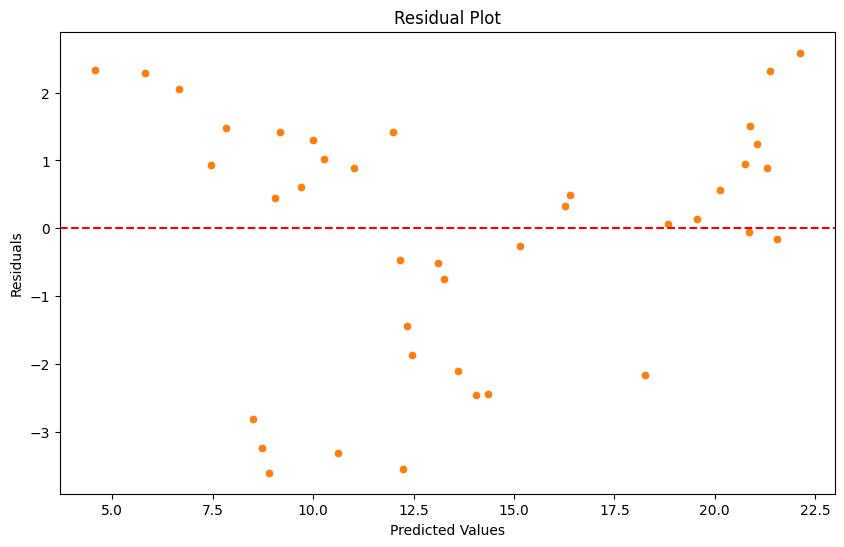

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
sns.scatterplot(x=y_pred ,y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()